<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <h1>Breast Cancer data process</h1>
</div>

<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <h2>This notebook :</h2>
    <p>
    - Loads cleaned data<br>
    - Searches collinearity with the target<br>
    - Searches collinearity between features<br>
    - drops data<br>
    - application of the same feature reduction to both X_train ans X_test<br>
    - preprocessor's selection and execution<br>
    - exploratory PCA analysis<br>
    - Saves ... `data/data_processed`<br>
    </p>
</div>

In [2]:

import math

import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from building_perceptron.cleaning_utils import preprocess_data


from building_perceptron.config import CLEAN_DATA_DIR, TARGET, PROCESSED_DATA_DIR
from building_perceptron.eda_utils import (
    correlated_features,
    drop_redundant_features,
    plot_features_correlations,
    plot_numeric_histograms,
    plot_scatter_vs_target,
    plot_target_correlations,
    scree_plot,
    target_correlations,
    plot_correlation_circle
)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <h2>Import the source files with the proper encoding</h2>
</div>

In [3]:
X_train = CLEAN_DATA_DIR / "X_train.csv"
y_train = CLEAN_DATA_DIR / "y_train.csv"
X_test = CLEAN_DATA_DIR / "X_test.csv"
y_test = CLEAN_DATA_DIR / "y_test.csv"


X_train = pd.read_csv(X_train, encoding='ascii')
y_train = pd.read_csv(y_train, encoding='ascii')
X_test = pd.read_csv(X_test, encoding='ascii')
y_test = pd.read_csv(y_test, encoding='ascii')

y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

In [4]:
print(f"\
    X_train type: {type(X_train)}\n\
    X_train shape : {X_train.shape}\n\
    y_train type : {type(y_train)}\n\
    y_train shape : {y_train.shape}"
    )

    X_train type: <class 'pandas.DataFrame'>
    X_train shape : (455, 30)
    y_train type : <class 'numpy.ndarray'>
    y_train shape : (455,)


<div style="background-color: #439cc8; color: white; padding: 10px; border-radius: 8px;">
<h2>Correlation with the Target</h2>
<p>Identify which features have the strongest predictive power regarding the diagnosis.</p>
</div>

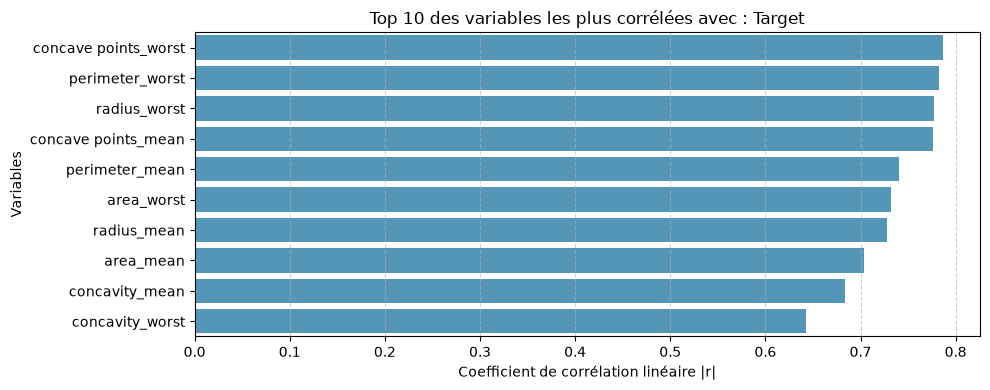

In [5]:
plot_target_correlations(X_train, y_train, n_top=10, figsize=(10, 4))

In [6]:
top_correlations = target_correlations(X_train, y_train, n_top=10)

top_corr_cols = top_correlations.index.tolist()

print(f"Top 10 features most correlated with {TARGET} :\n")
print(top_corr_cols)

Top 10 features most correlated with diagnosis :

['concave points_worst', 'perimeter_worst', 'radius_worst', 'concave points_mean', 'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean', 'concavity_mean', 'concavity_worst']


<div style="background-color: #439cc8; color: white; padding: 10px; border-radius: 8px;">
<h2>Dimension Reduction</h2>
<p>To maintain biological interpretability, feature selection is prefered to PCA</p>
Many features are derived from the same biological metrics, and are highly collinear (e.g., radius, perimeter, area)<br>
Keeping them all would introduce noise and instability into our model.</p>
</div>

<div style="background-color: #439cc8; color: white; padding: 10px; border-radius: 8px;">
<h3>Feature Collinearity (Redundancy)</h3>
<p>A general overview of Feature Collinearity</p>
</div>

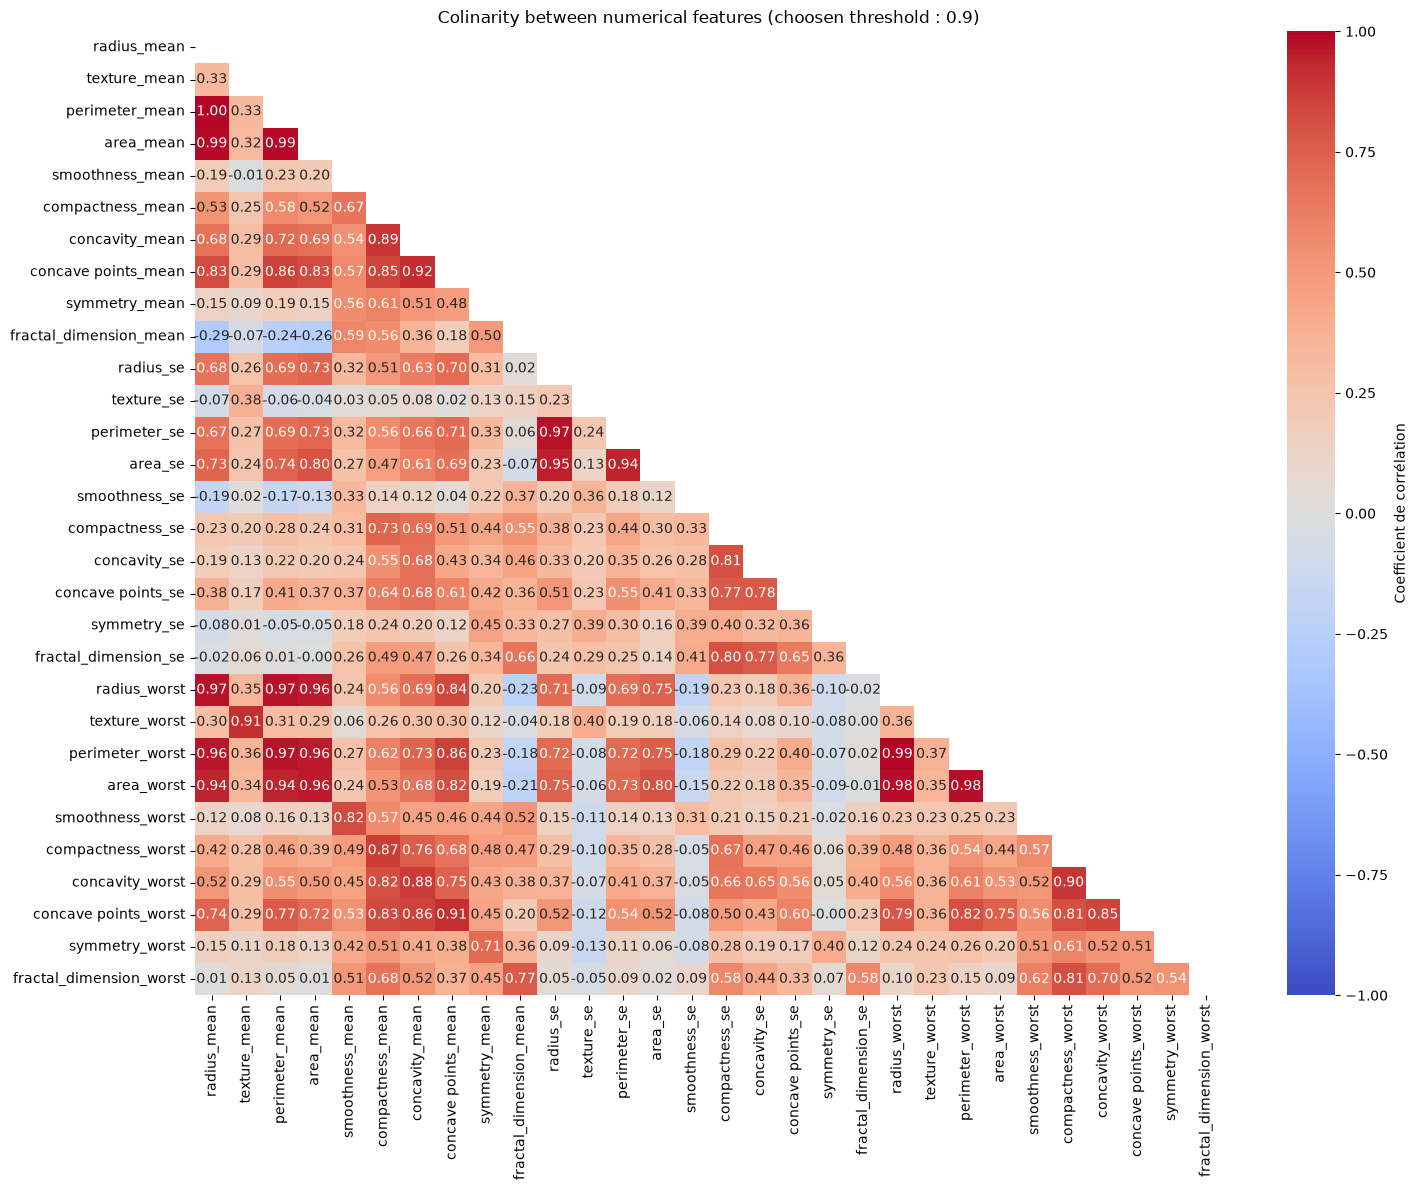

In [7]:
plot_features_correlations(X_train, threshold=0.90,figsize=(15, 12))

<div style="background-color: #439cc8; color: white; font-size: 16px; font-style: italic; padding: 10px 15px; margin-bottom: 15px; border-radius: 8px;">
<h3>Focus on highly correlated features.</h3>
<p>Threshold is set at : |r| > 0.90</p>
<p>Pairs of features above this threshold are strong candidates for removal</p>
<ul>
    <li>evaluate their individual correlation with the target</li>
    <li>Keep the most predictive one and drop the redundant feature.</li>
</ul>
</div>

In [8]:
collinear_pairs = correlated_features(X_train, threshold=0.90)
print(f"Number of highly collinear pairs (|r| > 0.90): {len(collinear_pairs)}\n")

# Display the pairs as a table, (requires to to  calculate column widths first)
feature_1_max_width = max(len(pair[0]) for pair in collinear_pairs)
feature_2_max_width = max(len(pair[1]) for pair in collinear_pairs)

for pair in collinear_pairs:
    print(f"{pair[0]:<{feature_1_max_width}} <->   {pair[1]:<{feature_2_max_width}} correlation: {pair[2]:.2f}")

Number of highly collinear pairs (|r| > 0.90): 21

perimeter_mean       <->   radius_mean         correlation: 1.00
perimeter_worst      <->   radius_worst        correlation: 0.99
area_mean            <->   radius_mean         correlation: 0.99
area_mean            <->   perimeter_mean      correlation: 0.99
area_worst           <->   radius_worst        correlation: 0.98
area_worst           <->   perimeter_worst     correlation: 0.98
perimeter_se         <->   radius_se           correlation: 0.97
perimeter_worst      <->   perimeter_mean      correlation: 0.97
radius_worst         <->   perimeter_mean      correlation: 0.97
radius_worst         <->   radius_mean         correlation: 0.97
perimeter_worst      <->   radius_mean         correlation: 0.96
radius_worst         <->   area_mean           correlation: 0.96
area_worst           <->   area_mean           correlation: 0.96
perimeter_worst      <->   area_mean           correlation: 0.96
area_se              <->   radius_se   

In [9]:
for col in top_corr_cols:
    print(f"\n{col}")

    print(
        X_train.assign(target=y_train)
        .groupby("target")[col]
        .agg(["count", "nunique", "std", "var"])
    )


concave points_worst
        count  nunique       std       var
target                                    
0         285      247  0.036710  0.001348
1         170      164  0.048137  0.002317

perimeter_worst
        count  nunique        std         var
target                                       
0         285      277  13.582099  184.473411
1         170      157  30.076510  904.596446

radius_worst
        count  nunique       std        var
target                                     
0         285      226  1.982445   3.930089
1         170      157  4.348061  18.905636

concave points_mean
        count  nunique       std       var
target                                    
0         285      269  0.015582  0.000243
1         170      167  0.035734  0.001277

perimeter_mean
        count  nunique        std         var
target                                       
0         285      274  11.838256  140.144314
1         170      156  22.514690  506.911255

area_worst
        co

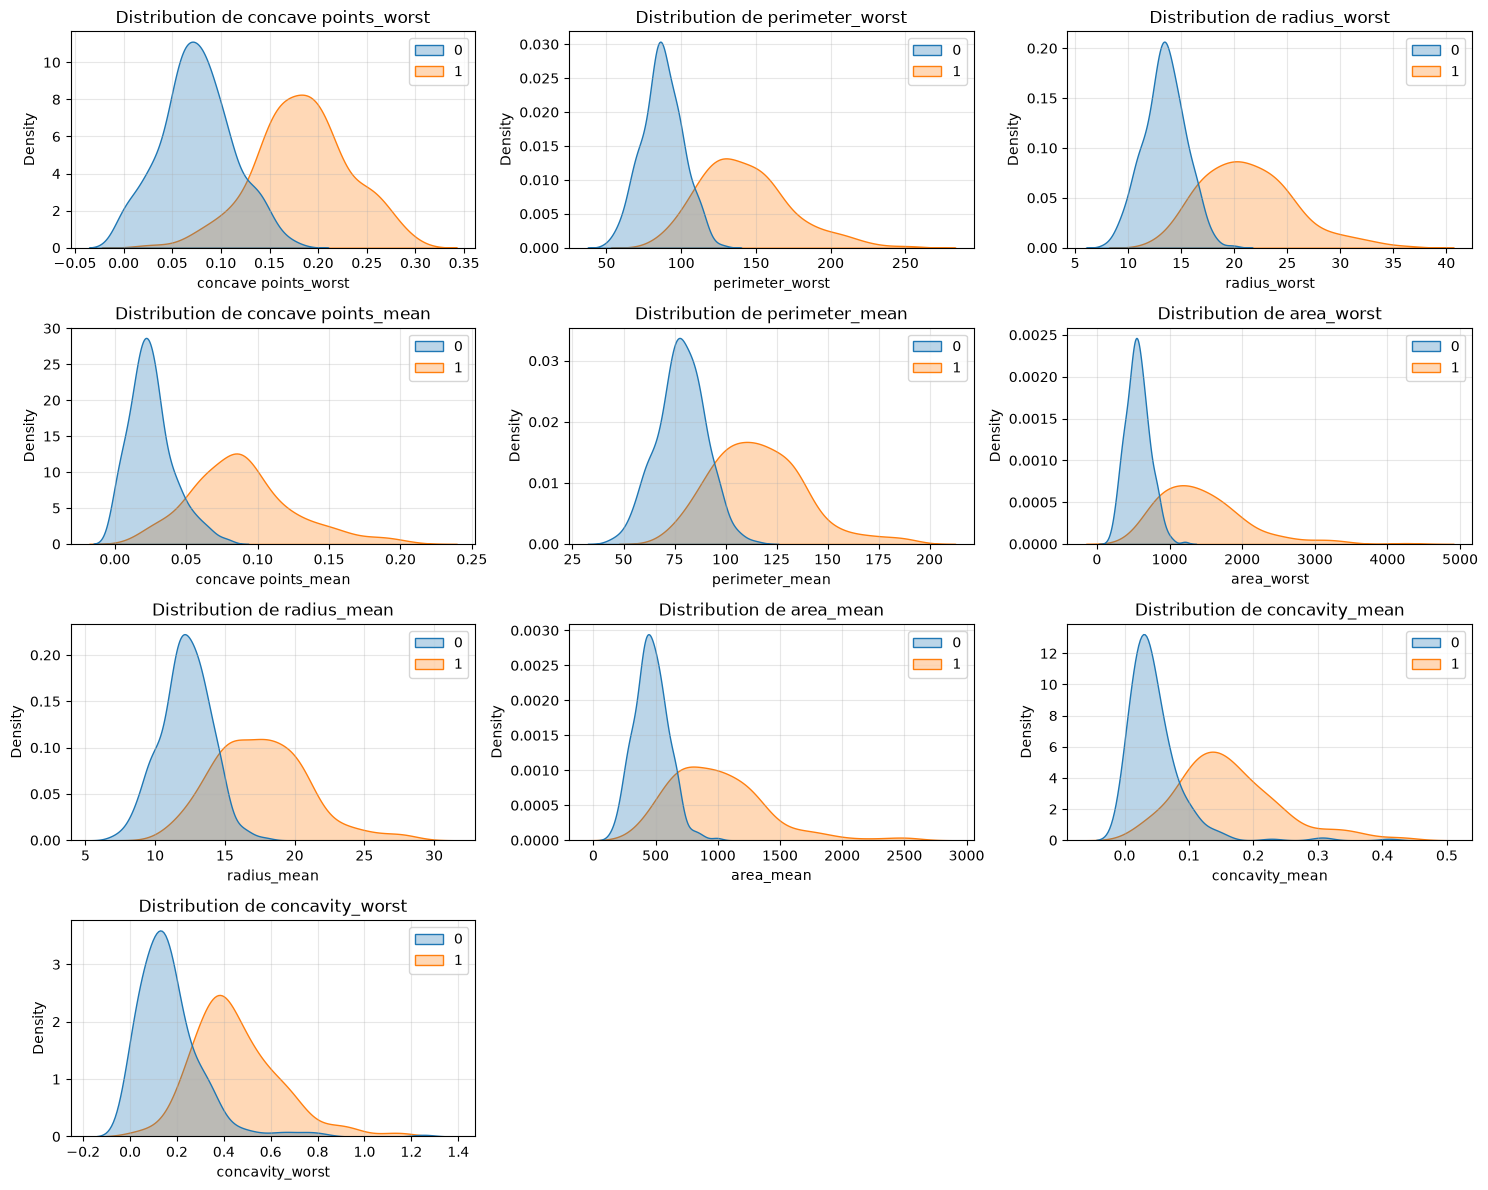

In [10]:
n_cols = 3
n_rows = math.ceil(len(top_corr_cols) / n_cols)
plt.figure(figsize=(15, 3 * n_rows))

# reduire la taille de la figure pour que les sous-graphes soient plus lisibles
# plt.subplots_adjust(hspace=0.4, wspace=0.3)

for i, col in enumerate(top_corr_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.kdeplot(data=X_train, x=col, hue=y_train, common_norm=False, fill=True, alpha=0.3)
    plt.title(f"Distribution de {col}")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

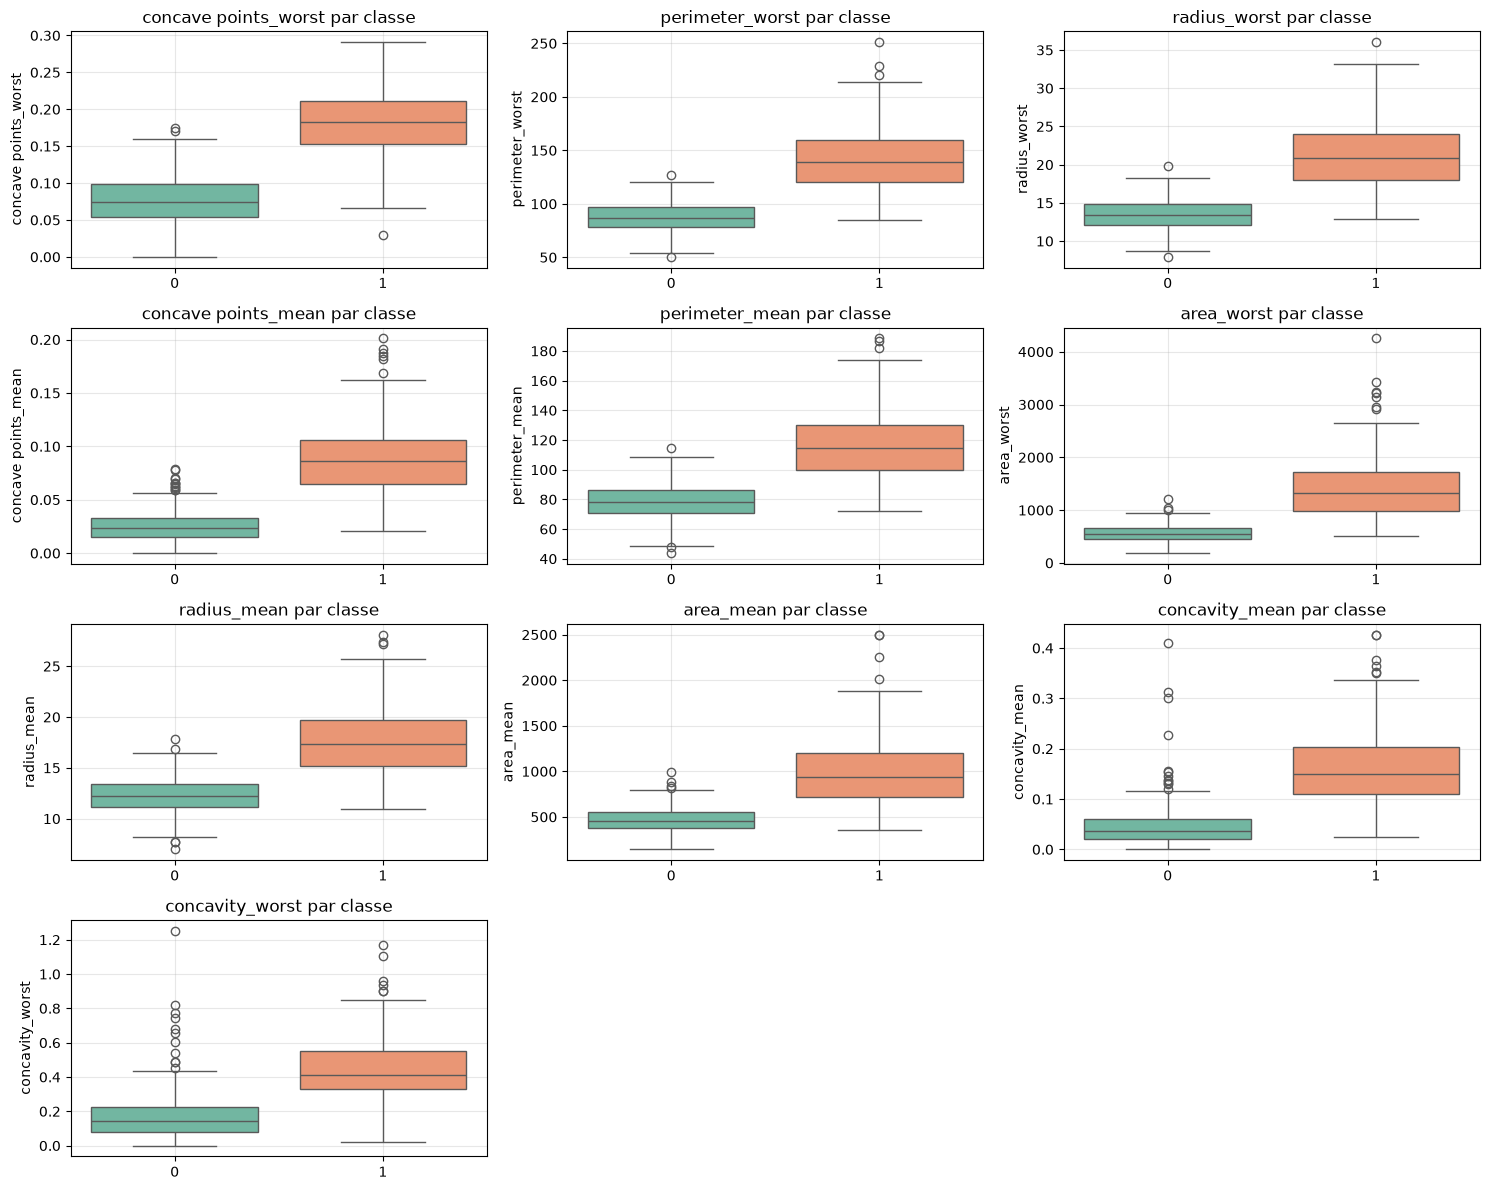

In [11]:
plt.figure(figsize=(15, 3 * n_rows))

for i, col in enumerate(top_corr_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=y_train, y=X_train[col], palette="Set2", hue=y_train, legend=False)
    plt.title(f"{col} par classe")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<div style="background-color: #439cc8; color: white; font-size: 16px; font-style: italic; padding: 10px 15px; margin-bottom: 15px; border-radius: 8px;">
  <h3>Features removal</h3>
</div>


In [12]:
# Application de la fonction de réduction (qui inclut déjà la logique métier)
X_train_reduced, dropped_cols = drop_redundant_features(X_train, y_train, threshold=0.90)

print(f"Initial number of features : {X_train.shape[1]}")
print(f"Features dropped due to redundancy : {len(dropped_cols)}")
print(f"Remaining features : {X_train_reduced.shape[1]}\n")
print(f"Remaining features:\n{X_train_reduced.columns.tolist()}\n")

print("List of dropped features:")
print(dropped_cols)
print(f"\nRemaining features:\n{X_train_reduced.columns.tolist()}\n")

Initial number of features : 30
Features dropped due to redundancy : 10
Remaining features : 20

Remaining features:
['smoothness_mean', 'compactness_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'texture_worst', 'perimeter_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

List of dropped features:
['area_mean', 'area_se', 'area_worst', 'concave points_mean', 'concavity_mean', 'perimeter_mean', 'perimeter_se', 'radius_mean', 'radius_worst', 'texture_mean']

Remaining features:
['smoothness_mean', 'compactness_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'texture_worst', 'perimeter_worst', 'smoothness_worst', 'compactnes

<div style="background-color: #439cc8; color: white; padding: 10px; border-radius: 8px;">
<h4>the same transformation is applied to the test set</h4>
</div>

In [13]:
X_test_reduced = X_test.drop(columns=dropped_cols, errors="ignore")

assert list(X_train_reduced.columns) == list(X_test_reduced.columns)


<div style="background-color: #439cc8; color: white; padding: 10px; border-radius: 8px;">
<h4>Scaling</h4>
<p>To choose the proper scaler :<br>
Analyse the numerical feature's distribution </p>
</div>

In [15]:
for var in X_train_reduced.columns:
    fig = px.box(
        X_train_reduced,
        x=var,
        title=f"{var} distribution",
        height=100
    )

    # Reduce margins
    fig.update_layout(
        margin=dict(l=20, r=20, t=35, b=20),
        title=dict(font=dict(size=13)),  # Titre légèrement plus compact
    )

    # Suppress x labels
    fig.update_xaxes(title=None)
    fig.show()

<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%; color: #439cc8" >
<h4 style="margin: auto; padding: 20px; ">Scaler selection</h4>

1.  Information preservation :<br>
The dataset presents asymetrical distributions : <strong>outliers in the high values</strong><br>
<br>
Using `RobustScaler`, the median and the interquartile space ($IQR$),  normalization is done without flatening the healthy data variance

2. model performance :<br>
Perceptron is sensible to the features scale<br>
during training, the weights adjustment can be accelerated and stabilised if features have a similar scale<br>
`RobustScaler` garanties that outliers won't cause excessive distorsions in the computing of the separation hyperplan

3. Biological nature :<br>
From a biological point of vue, those outliers represent cellular anomalies that are critical for the diagnosis.<br><br>
it is imperative to use a scaler that normalises the features scales without suppressing nor masking the outliers signal
</div>

In [16]:
# Show values of the first observation before scaling
print(X_train_reduced[:1].values)
print(f"max: {X_train_reduced[:1].values.max()}")
print(f"min: {X_train_reduced[:1].values.min()}")

[[8.206e-02 6.669e-02 1.528e-01 5.697e-02 3.795e-01 1.187e+00 4.029e-03
  9.269e-03 1.101e-02 7.591e-03 1.460e-02 3.042e-03 3.388e+01 1.238e+02
  1.181e-01 1.551e-01 1.459e-01 9.975e-02 2.948e-01 8.452e-02]]
max: 123.8
min: 0.003042


<div style="background-color: #439cc8; color: white; padding: 10px; border-radius: 8px;">
<h4>Scaling</h4>
<p>`RobustScaler` :<br>
scaled_value = (value - median) / IQR<br>
each features median is shifted to 0<br>
each features values are comparables<br>
outliers are less influent than with a scaling based on the mean and the standard<br>
some values can still be >1 or <-1
</div>

In [17]:
# Preprocessing with RobustScaler()
X_train_scaled, X_test_scaled, preprocessor = preprocess_data(X_train_reduced, X_test_reduced)


In [18]:
# Show values of the first observation after scaling
print(X_train_scaled[:1])
print(f"max: {X_train_scaled[:1].max()}")
print(f"min: {X_train_scaled[:1].min()}")

[[-0.66666667 -0.38414771 -0.8125937  -0.49570693  0.20728068  0.07574562
  -0.75316349 -0.57230688 -0.58292444 -0.47724495 -0.51314143 -0.03904365
   0.96440873  0.61005482 -0.40561622 -0.32361439 -0.31499906 -0.01275185
   0.18518519  0.21380309]]
max: 0.964408725602756
min: -0.8125937031484264


<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<p style="margin: auto; padding: 20px; color: #439cc8; ">
These NumPy arrays confirm that preprocessing was successful.

The features are now expressed relative to their median and interquartile range. Values such as -0.66, 0.20, and 0.96 illustrate the transformed scale.

Before scaling, the features had very different magnitudes: tumor radii were typically around 15, while area measurements could reach values close to 1000.

After scaling, the features are on comparable scales. The Perceptron is therefore less affected by differences in measurement units and can learn more stable weights.

Note that RobustScaler does not constrain all values to the [-1, 1] interval. Extreme observations may still produce values outside this range.
</p>
</div>

<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">Verify the transformed test features</h3>
</div>

In [19]:
X_train_scaled_df = pd.DataFrame(X_train_scaled)

stats = pd.DataFrame({
    "median": X_train_scaled_df.median(),
    "min": X_train_scaled_df.min(),
    "max": X_train_scaled_df.max(),
    "iqr": X_train_scaled_df.quantile(0.75)
           - X_train_scaled_df.quantile(0.25),
})

print(stats)

    median       min        max  iqr
0      0.0 -1.655539   3.447648  1.0
1      0.0 -1.094348   3.799745  1.0
2      0.0 -2.215892   3.721139  1.0
3      0.0 -1.266171   4.137378  1.0
4      0.0 -0.858962  10.127710  1.0
5      0.0 -1.228973   5.911315  1.0
6      0.0 -1.534672   8.391766  1.0
7      0.0 -0.941040   4.531792  1.0
8      0.0 -1.015113  14.529539  1.0
9      0.0 -1.568768   6.022000  1.0
10     0.0 -1.353942   7.540676  1.0
11     0.0 -0.981005  11.717043  1.0
12     0.0 -1.545350   2.762342  1.0
13     0.0 -1.102065   3.582177  1.0
14     0.0 -1.869891   2.854914  1.0
15     0.0 -0.995062   4.419753  1.0
16     0.0 -0.862775   3.837807  1.0
17     0.0 -1.030349   1.938281  1.0
18     0.0 -1.863704   5.651852  1.0
19     0.0 -1.208977   6.149131  1.0


<div style="background-color: #439cc8; color: white; padding: 10px; border-radius: 8px;">
<h4>Export</h4>
<p>processed datasets are exported to `data/processed_data`</p>
</div>

In [20]:
# Ensure the output directory `data/processed_data` exists
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

# Features: RobustScaler outputs, ready for the Perceptron (model.ipynb)
pd.DataFrame(X_train_scaled, columns=X_train_reduced.columns).to_csv(
    PROCESSED_DATA_DIR / "X_train_scaled.csv", index=False
)
pd.DataFrame(X_test_scaled, columns=X_test_reduced.columns).to_csv(
    PROCESSED_DATA_DIR / "X_test_scaled.csv", index=False
)

# Targets: kept as labeled columns for traceability
pd.DataFrame(y_train, columns=[TARGET]).to_csv(
    PROCESSED_DATA_DIR / "y_train.csv", index=False
)
pd.DataFrame(y_test, columns=[TARGET]).to_csv(
    PROCESSED_DATA_DIR / "y_test.csv", index=False
)

print(f"Exports written to {PROCESSED_DATA_DIR}")

Exports written to /home/coule/Documents/projets/building-perceptron/data/processed_data


<div style="background-color: #439cc8; color: white; padding: 10px; border-radius: 8px;">
<h4 style="margin: auto; padding: 20px;">Non supervised PCA exploratory analysis</h4>

<p style="margin: auto; padding: 0 20px 20px 20px;">
`RobustScaler` is not suitable for <strong>Principal Component Analysis</strong><br>
`StandardScaler` is better<br>
It means we have to go back to X_train_reduced to redo the scaling<br>
</p>
<p style="margin: auto; padding: 0 20px 20px 20px;">
Objectif : analyser la structure intrinsèque des variables explicatives uniquement (<strong>X</strong>).<br>
Interprétation : lecture plus fidèle des corrélations et de la redondance entre features.<br>
Usage recommandé : cette version est la référence pour comprendre la géométrie des données avant modélisation.
</p>
</div>

In [21]:
# Preprocessing with StandardScaler()
X_train_std, _, _ = preprocess_data(X_train_reduced, scaler=StandardScaler())

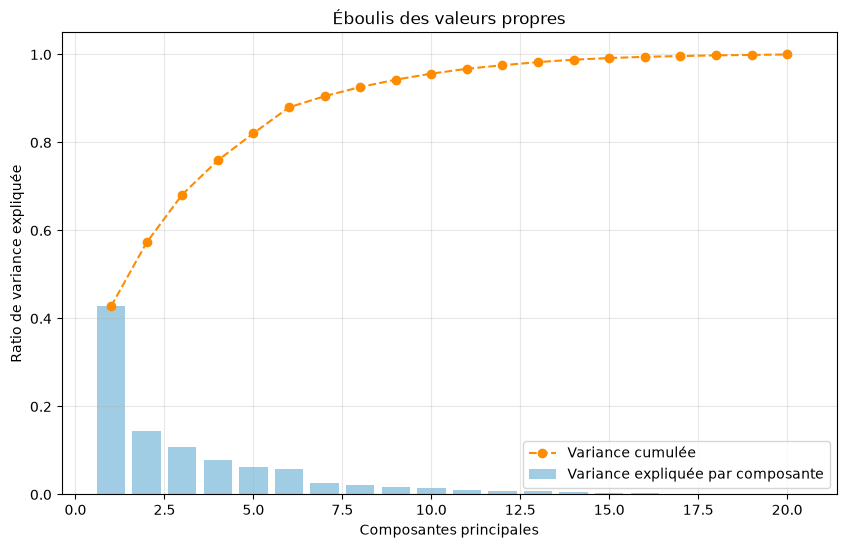

In [22]:
pca_model = PCA()
# Fit data and extract components
X_train_pca = pca_model.fit_transform(X_train_std)
# Génération du graphique des éboulis en passant l'instance du modèle
scree_plot(pca_model)

<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%; color: #439cc8">
<h4 style="margin: auto; padding: 20px;">PCA results</h4>

<p style="margin: auto; padding: 0 20px 20px 20px;">
Comp. 1 at ~40%: dominant, expected overall size effect<br>
even after removing redundancies, most of the remaining features measure quantities related to the size and shape of cell nuclei.</p>

<p style="margin: auto; padding: 0 20px 20px 20px;">
Elbow after the 2nd component<br>
the first two components carry the bulk of the structure but account for only ~57% of the total.</p>

<p style="margin: auto; padding: 0 20px 20px 20px;">
~90% of the variance is explained by the 7th component<br>
7 dimensions out of 20 are required to capture 90% of the information. The compression ratio is modest—which is to be expected after having already eliminated strong collinearities (|r| > 0.90). PCA would offer little benefit here.</p>

<p style="margin: auto; padding: 0 20px 20px 20px;">
Final components (~0–1% each): residual noise, of no interest.</p>

<h4 style="margin: auto; padding: 20px;">conclusion</h4>
<p style="margin: auto; padding: 0 20px 20px 20px;">
After removing the 10 redundant features, the remaining 20 do not lend themselves well to PCA-based compression<br>
(requiring 7 components to capture 90% of the variance)<br><br>
Feature selection has already handled the task of removing collinearit<br>
performing an additional PCA would sacrifice biological interpretability for only a modest reduction in dimensionality<br>
Retain the 20 scaled features for the Perceptron.

</div>

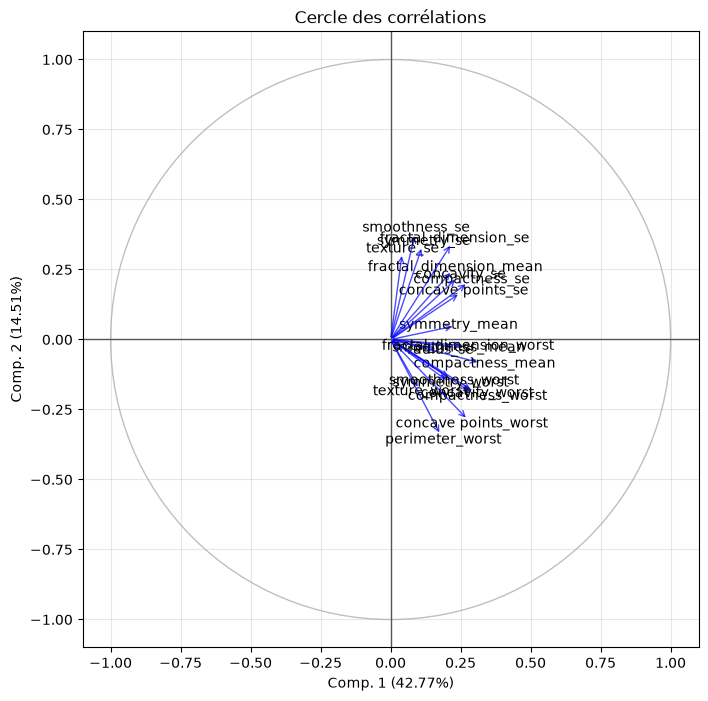

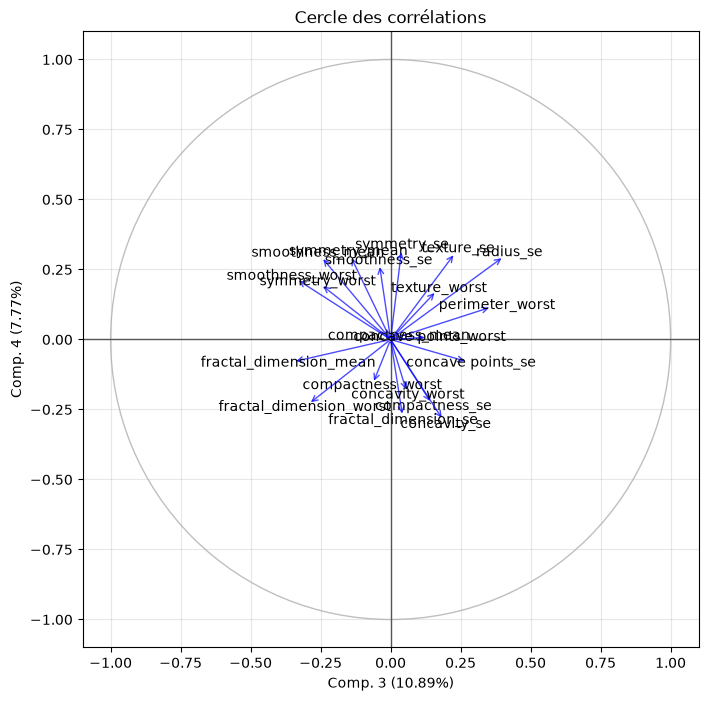

In [23]:
# Correlation circle on the first two principal components
plot_correlation_circle(pca_model, (0, 1), X_train_reduced.columns.tolist())
# And on components 3 and 4
plot_correlation_circle(pca_model, (2, 3), X_train_reduced.columns.tolist())


<div  style="border: 1px solid #439cc8;border-radius: 8px;width:95%; color: #439cc8">
<h4>Correlation circle analysis (Comp. 1 x Comp. 2)</h4>
<p style="margin: auto; padding: 0 20px 20px 20px;">
The first two components capture <strong>57.3%</strong> of the total variance
(42.8% + 14.5%). On a standardized 20-feature dataset, this indicates a dominant
but not exclusive global structure.
</p>
<ul>
<li><strong>No arrow reaches the unit circle.</strong> Every feature keeps a substantial
part of its variance outside this plane. Directions and groupings remain interpretable
(angles between arrows), but individual correlations with each axis are moderate —
no feature is fully summarized by Comp. 1 and Comp. 2 alone.</li>
<li><strong>Comp. 1 (42.8%) — global tumor severity axis.</strong>
<code>perimeter_worst</code> and <code>concave points_worst</code> point to the right,
positively correlated with Comp. 1: larger, more irregular contours drive the first
component. Features on the left side contribute negatively.</li>
<li><strong>Comp. 2 (14.5%) — fine-grained irregularity axis.</strong> The upper
cluster (<code>smoothness_se</code>, <code>fractal_dimension_se</code>,
<code>symmetry_mean</code>, <code>texture_se</code>, <code>compactness_se</code>)
varies together and independently from the size block: it describes local texture
and shape dispersion, orthogonal to overall magnitude.</li>
<li><strong>Two nearly independent biological axes.</strong> The small angles within each
cluster and the wide angle between clusters confirm that the retained features split
into two information blocks (magnitude vs. textural irregularity) with limited
redundancy between blocks — consistent with the threshold-based feature dropping
performed earlier ( |r| &gt; 0.90).</li>
<li><strong>Limit.</strong> Since arrows are short, conclusions on this plane should be
cross-checked against the scree plot and the Comp. 3 x Comp. 4 circle before drawing
final structural conclusions.</li>
</ul>
<p style="margin: auto; padding: 0 20px 20px 20px;">
<strong>Takeaway:</strong> the diagnosis-relevant information is structured along two
quasi-orthogonal axes (overall magnitude on Comp. 1, texture/regularity on Comp. 2).
The plane is informative but partial — a good argument for keeping interpretable raw
features rather than projecting onto PCA components for the Perceptron.
</p>
</div>


<div style="background-color: #439cc8; color: white; padding: 10px; border-radius: 8px;">
<h4>Feature-name alignment check</h4>
<p>
The PCA is fitted on <code>X_train_std</code>, a NumPy array produced by the preprocessor<br>
Arrays carry no column names, so the correlation circle is labelled by reusing
<code>X_train_reduced.columns</code>.
</p>
<p>
This mapping is valid only if both structures have the same width<br>
<code>StandardScaler</code> transforms each column independently, without adding,
removing, or reordering any<br>
so the alignment should hold by construction —
but a silent mismatch (wrong input dataframe, stale variable from a previous run,<br>
or a future preprocessor that expands categorical columns) would shift every label
on the circle and invalidate the interpretation without raising any error.
</p>
<p>
The assertion makes that implicit contract explicit: it succeeds silently when the
number of PCA input columns equals the number of feature names, and raises an
<code>AssertionError</code> at the exact moment the labels can no longer be trusted.
</p>
</div>

In [24]:
assert pca_model.components_.shape[1] == len(X_train_reduced.columns)